<a href="https://colab.research.google.com/github/Diegoggonfer/Modelos/blob/main/Modelo_DRP_3_Prediccion_sobre_datos_de_glioma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Carga Inicial de Datos

In [ ]:
import pandas as pd

# Cargar los datos
data = pd.read_csv('/content/drive/MyDrive/TFM/nuevo set/GDSC_DATASET.csv')

print("Nombres de las columnas:")
print(data.columns.tolist())

print("\nDimensiones del dataset:")
print(data.shape)

print("\nPrimeras 5 filas del dataset:")
display(data.head())

Nombres de las columnas:
['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']

Dimensiones del dataset:
(242035, 19)

Primeras 5 filas del dataset:


,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


### Preprocesamiento de los Datos

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar los datos
data = pd.read_csv('/content/drive/MyDrive/TFM/nuevo set/GDSC_DATASET.csv')

# Filtrar el dataset por 'GDSC Tissue descriptor 2'
initial_rows_count = data.shape[0]
data = data[data['GDSC Tissue descriptor 2'].isin(['glioma'])]
print(f"Filas después de filtrar por 'GDSC Tissue descriptor 1': {data.shape[0]} (original: {initial_rows_count})")

# Eliminar filas sin variable objetivo y separarla del resto.
# Esta debe ser la primera operación para asegurar que el target sea limpio y consistente.
original_rows_count = data.shape[0]
data.dropna(axis=0, subset=['LN_IC50'], inplace=True)
target = data['LN_IC50']
data.drop(['LN_IC50'], axis=1, inplace=True)
print(f"Filas después de eliminar NaNs en LN_IC50: {data.shape[0]} (original: {original_rows_count})")

# Columnas a eliminar según la nueva solicitud del usuario
columns_to_drop = ['COSMIC_ID', 'DRUG_ID', 'AUC', 'Z_SCORE']
data.drop(columns=columns_to_drop, errors='ignore', inplace=True)
print(f"Filas después de eliminar columnas especificadas: {data.shape[0]}")

# Identificar columnas numéricas y categóricas para un manejo diferenciado
numeric_cols = []
categorical_cols = []

for col in data.columns:
    # Intentar convertir la columna a numérica. Los errores se convierten en NaN.
    temp_series = pd.to_numeric(data[col], errors='coerce')

    # Si la serie temporal tiene un tipo numérico (float o int) Y NO está compuesta enteramente de NaNs (lo que indicaría que no se pudo convertir nada útil)
    # y la proporción de valores no NaN es alta, la consideramos numérica.
    # Usamos un umbral para considerar que una columna es principalmente numérica.
    non_nan_ratio = temp_series.count() / data[col].count()
    if pd.api.types.is_numeric_dtype(temp_series) and non_nan_ratio > 0.5: # Si más del 50% de los valores pudieron ser convertidos a numéricos
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"\nColumnas Numéricas Identificadas: {numeric_cols}")
print(f"Columnas Categóricas Identificadas: {categorical_cols}")

# Manejar columnas numéricas: eliminar filas con NaNs
print(f"\nFilas antes de eliminar NaNs en columnas numéricas: {data.shape[0]}")
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce') # Asegurar que sean numéricas, convirtiendo cualquier texto no numérico a NaN
data.dropna(subset=numeric_cols, inplace=True) # Eliminar filas donde estas columnas numéricas tienen NaNs
target = target.loc[data.index] # Reajustar el target después de eliminar filas
print(f"Filas después de eliminar NaNs en columnas numéricas: {data.shape[0]}")

# Manejar columnas categóricas: reemplazar NaN y 'Unclassified' con 'Desconocido'
print(f"\nFilas antes de procesar columnas categóricas: {data.shape[0]}")
for col in categorical_cols:
    # Convertir a tipo string para asegurar que .replace() y .fillna() funcionen correctamente
    data[col] = data[col].astype(str)
    data[col] = data[col].replace('Unclassified', "Desconocido") # Reemplazar 'Unclassified'
    data[col] = data[col].replace('UNCLASSIFIED', "Desconocido") # Reemplazar 'Unclassified'
    data[col] = data[col].replace('nan', "Desconocido") # Reemplazar NaNs que se hayan convertido a string 'nan'
    data[col] = data[col].fillna("Desconocido") # Rellenar cualquier NaN remanente

print(f"Filas después de procesar columnas categóricas: {data.shape[0]}")

# Separar el set de validación del de entrenamiento
X_train, X_valid, y_train, y_valid = train_test_split(data, target, train_size=0.8, test_size=0.2, random_state=0)

print("\nDimensiones de X_train:")
print(X_train.shape)
print("Primeras 5 filas de X_train:")
display(X_train.head())

print("\nDimensiones de y_train:")
print(y_train.shape)
print("Primeras 5 filas de y_train:")
display(y_train.head())

Filas después de filtrar por 'GDSC Tissue descriptor 1': 11822 (original: 242035)
Filas después de eliminar NaNs en LN_IC50: 11822 (original: 11822)
Filas después de eliminar columnas especificadas: 11822

Columnas Numéricas Identificadas: []
Columnas Categóricas Identificadas: ['CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_NAME', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']

Filas antes de eliminar NaNs en columnas numéricas: 11822
Filas después de eliminar NaNs en columnas numéricas: 11822

Filas antes de procesar columnas categóricas: 11822
Filas después de procesar columnas categóricas: 11822

Dimensiones de X_train:
(9457, 14)
Primeras 5 filas de X_train:


,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
13317,no-11,LGG,Bosutinib,nervous_system,glioma,LGG,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,"SRC, ABL, TEC","Other, kinases"
227176,U251,GBM,GSK-LSD1-2HCl,nervous_system,glioma,GBM,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,LSD1,Chromatin histone methylation
54474,DK-MG,GBM,Irinotecan,nervous_system,glioma,GBM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
151213,LN-405,GBM,Nelarabine,nervous_system,glioma,GBM,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,Desconocido,DNA replication
62966,GB-1,GBM,Niraparib,nervous_system,glioma,GBM,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,"PARP1, PARP2",Genome integrity



Dimensiones de y_train:
(9457,)
Primeras 5 filas de y_train:


,LN_IC50
13317,4.858186
227176,3.625147
54474,5.590053
151213,6.676407
62966,4.539875


### Análisis de los valores desconocidos en el dataset

In [ ]:
print("\nAnálisis de valores 'Desconocidos' por columna:")
total_rows = data.shape[0]

unknown_counts = {}
unknown_percentages = {}

for col in data.columns:
    if data[col].dtype == 'object': # Solo para columnas que pueden contener strings 'Desconocido'
        count = (data[col] == 'Desconocido').sum()
        if count > 0:
            unknown_counts[col] = count
            unknown_percentages[col] = (count / total_rows) * 100

if unknown_counts:
    print("Número de valores 'Desconocidos' por columna:")
    for col, count in unknown_counts.items():
        print(f"  - {col}: {count}")

    print("\nPorcentaje de valores 'Desconocidos' por columna:")
    for col, percentage in unknown_percentages.items():
        print(f"  - {col}: {percentage:.2f}%")
else:
    print("No se encontraron valores 'Desconocidos' en las columnas categóricas.")


Análisis de valores 'Desconocidos' por columna:
Número de valores 'Desconocidos' por columna:
  - TARGET: 1163
  - TARGET_PATHWAY: 1070

Porcentaje de valores 'Desconocidos' por columna:
  - TARGET: 9.84%
  - TARGET_PATHWAY: 9.05%


### Preprocesamiento de datos: One-Hot Encoding



In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import re # Importar la librería de expresiones regulares

# Identificar columnas categóricas
categorical_cols = X_train.select_dtypes(include='object').columns

# Crear un ColumnTransformer para aplicar OneHotEncoder solo a las columnas categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Mantener las columnas numéricas sin cambios
)

# Aplicar el preprocesamiento a los sets de entrenamiento y validación
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

# Convertir los resultados a DataFrame para facilitar la visualización y manejo

# Obtener los nombres de las columnas para las características codificadas
cat_feature_names_only = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

feature_names = cat_feature_names_only.copy() # Empezar con los nombres de las características categóricas

# Si hay columnas numéricas, añadirlas a los nombres de las características
# Las columnas 'remainder' se añaden al final en el orden original
numeric_cols = X_train.select_dtypes(exclude='object').columns.tolist()
feature_names.extend(numeric_cols)

X_train_encoded = pd.DataFrame(X_train_processed.toarray(), columns=feature_names, index=X_train.index)
X_valid_encoded = pd.DataFrame(X_valid_processed.toarray(), columns=feature_names, index=X_valid.index)

# Limpiar los nombres de las columnas para que sean compatibles con XGBoost y asegurar unicidad
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    seen_names = set()
    for col in cols:
        # Eliminar caracteres especiales que no le gustan a XGBoost y reemplazar espacios por guiones bajos
        new_col = re.sub(r'[\\\[\]<>]', '_', col) # Reemplazar [, ], <, >
        new_col = re.sub(r'[^a-zA-Z0-9_]', '', new_col) # Eliminar cualquier otro caracter no alfanumérico o guion bajo

        # Asegurar unicidad del nombre de columna
        original_new_col = new_col
        count = 1
        while new_col in seen_names:
            new_col = f"{original_new_col}_{count}"
            count += 1

        new_cols.append(new_col)
        seen_names.add(new_col)
    df.columns = new_cols
    return df

X_train_encoded = clean_col_names(X_train_encoded)
X_valid_encoded = clean_col_names(X_valid_encoded)

# Convertir las columnas de one-hot encoding a tipo booleano
# Asegurarse de que esta operación se haga después de la limpieza de nombres si se basa en nombres específicos
for col in X_train_encoded.columns:
    if X_train_encoded[col].dtype == 'float64' and X_train_encoded[col].isin([0.0, 1.0]).all():
        X_train_encoded[col] = X_train_encoded[col].astype(bool)
for col in X_valid_encoded.columns:
    if X_valid_encoded[col].dtype == 'float64' and X_valid_encoded[col].isin([0.0, 1.0]).all():
        X_valid_encoded[col] = X_valid_encoded[col].astype(bool)


print("Dimensiones de X_train_encoded:")
print(X_train_encoded.shape)
print("Primeras 5 filas de X_train_encoded:")
display(X_train_encoded.head())

print("\nDimensiones de X_valid_encoded:")
print(X_valid_encoded.shape)
print("Primeras 5 filas de X_valid_encoded:")
display(X_valid_encoded.head())

Dimensiones de X_train_encoded:
(9457, 562)
Primeras 5 filas de X_train_encoded:


,CELL_LINE_NAME_42MGBA,CELL_LINE_NAME_8MGBA,CELL_LINE_NAME_A172,CELL_LINE_NAME_AM38,CELL_LINE_NAME_Becker,CELL_LINE_NAME_CAS1,CELL_LINE_NAME_D245MG,CELL_LINE_NAME_D247MG,CELL_LINE_NAME_D263MG,CELL_LINE_NAME_D336MG,...,TARGET_PATHWAY_JNKandp38signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,TARGET_PATHWAY_Otherkinases,TARGET_PATHWAY_PI3KMTORsignaling,TARGET_PATHWAY_Proteinstabilityanddegradation,TARGET_PATHWAY_RTKsignaling,TARGET_PATHWAY_WNTsignaling,TARGET_PATHWAY_p53pathway
13317,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
227176,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54474,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
151213,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
62966,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Dimensiones de X_valid_encoded:
(2365, 562)
Primeras 5 filas de X_valid_encoded:


,CELL_LINE_NAME_42MGBA,CELL_LINE_NAME_8MGBA,CELL_LINE_NAME_A172,CELL_LINE_NAME_AM38,CELL_LINE_NAME_Becker,CELL_LINE_NAME_CAS1,CELL_LINE_NAME_D245MG,CELL_LINE_NAME_D247MG,CELL_LINE_NAME_D263MG,CELL_LINE_NAME_D336MG,...,TARGET_PATHWAY_JNKandp38signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,TARGET_PATHWAY_Otherkinases,TARGET_PATHWAY_PI3KMTORsignaling,TARGET_PATHWAY_Proteinstabilityanddegradation,TARGET_PATHWAY_RTKsignaling,TARGET_PATHWAY_WNTsignaling,TARGET_PATHWAY_p53pathway
48887,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
184340,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
170484,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
21176,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
231950,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Distribución de la variable objetivo en los sets de Entrenamiento y Validación

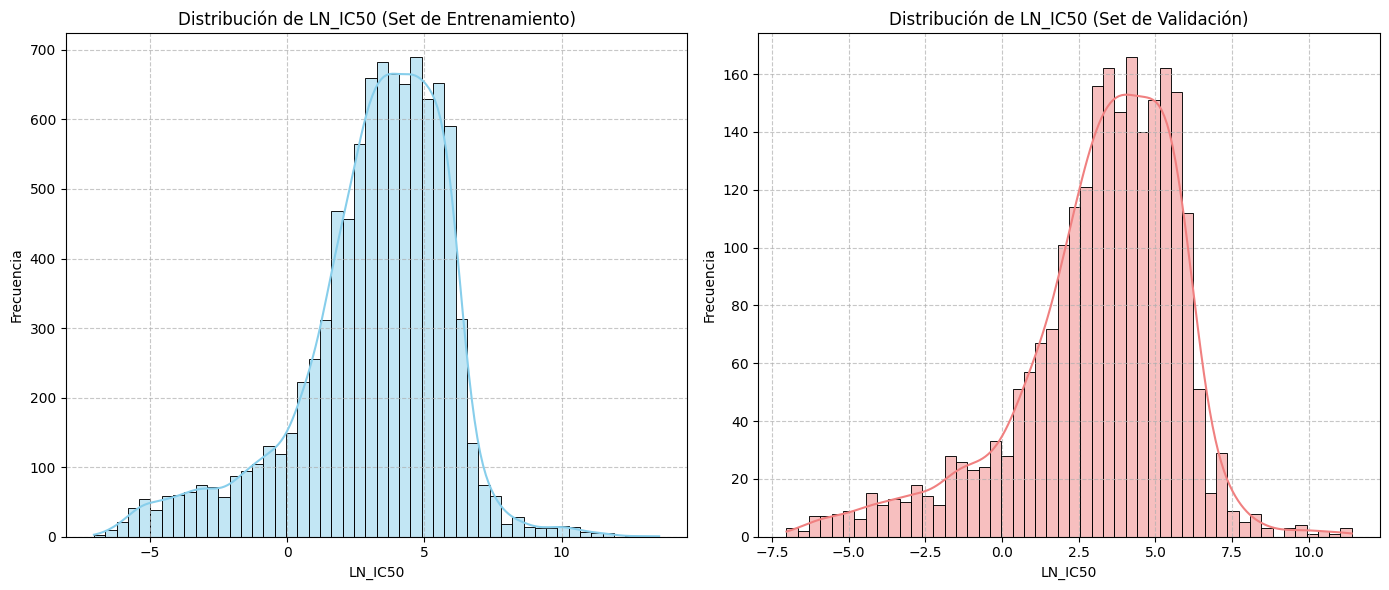

Estadísticas para y_train:
  Media: 3.1736
  Mediana: 3.5915
  Desviación Estándar: 2.7325

Estadísticas para y_valid:
  Media: 3.1872
  Mediana: 3.6200
  Desviación Estándar: 2.6805


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(y_train, kde=True, bins=50, color='skyblue')
plt.title('Distribución de LN_IC50 (Set de Entrenamiento)')
plt.xlabel('LN_IC50')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.histplot(y_valid, kde=True, bins=50, color='lightcoral')
plt.title('Distribución de LN_IC50 (Set de Validación)')
plt.xlabel('LN_IC50')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Estadísticas para y_train:")
print(f"  Media: {y_train.mean():.4f}")
print(f"  Mediana: {y_train.median():.4f}")
print(f"  Desviación Estándar: {y_train.std():.4f}")

print("\nEstadísticas para y_valid:")
print(f"  Media: {y_valid.mean():.4f}")
print(f"  Mediana: {y_valid.median():.4f}")
print(f"  Desviación Estándar: {y_valid.std():.4f}")

### Modelo de XGBoost Regressor



Entrenando XGBoost Regressor...
Entrenamiento completado.

Error Absoluto Medio (MAE) del XGBoost: 0.8160
Root Mean Squared Error (RMSE) para modelo_1 con nuevo filtro: 1.0649
R-squared (R2 Score) para modelo_1 con nuevo filtro: 0.8421


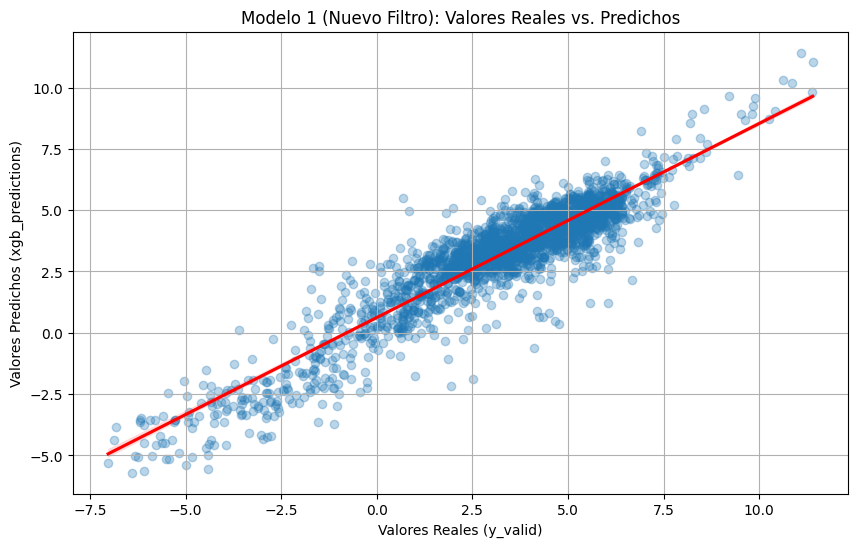

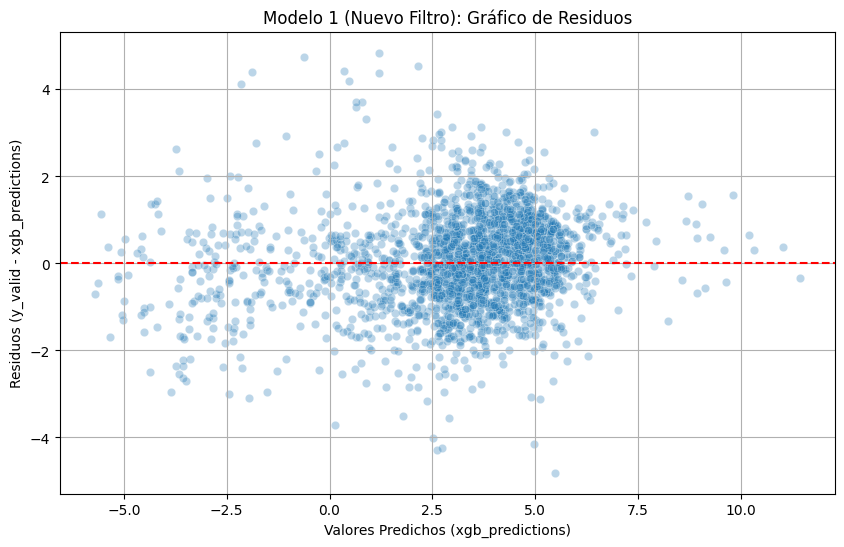

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=0) # n_jobs=-1 para usar todos los núcleos disponibles

# Entrenar el modelo
print("Entrenando XGBoost Regressor...")
xgb_model.fit(X_train_encoded, y_train,
              eval_set=[(X_valid_encoded, y_valid)], verbose=False) # Evaluar en el set de validación
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
xgb_predictions = xgb_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
xgb_mae = mean_absolute_error(y_valid, xgb_predictions)
print(f"\nError Absoluto Medio (MAE) del XGBoost: {xgb_mae:.4f}")

# Calcular RMSE
rmse_1_new = np.sqrt(mean_squared_error(y_valid, xgb_predictions))
print(f"Root Mean Squared Error (RMSE) para modelo_1 con nuevo filtro: {rmse_1_new:.4f}")

# Calcular R-squared
r2_1_new = r2_score(y_valid, xgb_predictions)
print(f"R-squared (R2 Score) para modelo_1 con nuevo filtro: {r2_1_new:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=xgb_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (xgb_predictions)')
plt.title('Modelo 1 (Nuevo Filtro): Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
residuals_1_new = y_valid - xgb_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=xgb_predictions, y=residuals_1_new, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (xgb_predictions)')
plt.ylabel('Residuos (y_valid - xgb_predictions)')
plt.title('Modelo 1 (Nuevo Filtro): Gráfico de Residuos')
plt.grid(True)
plt.show()

### Modelo de  CatBoost Regressor


In [ ]:
import sys
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


Entrenando CatBoost Regressor...
Entrenamiento completado.

Error Absoluto Medio (MAE) del CatBoost: 0.8063
Root Mean Squared Error (RMSE) del CatBoost: 1.0427
R-squared (R2 Score) del CatBoost: 0.8486


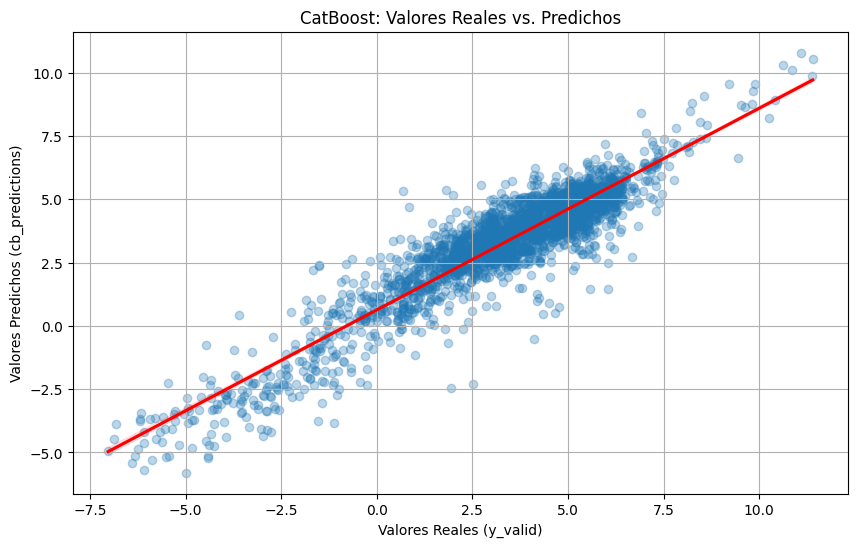

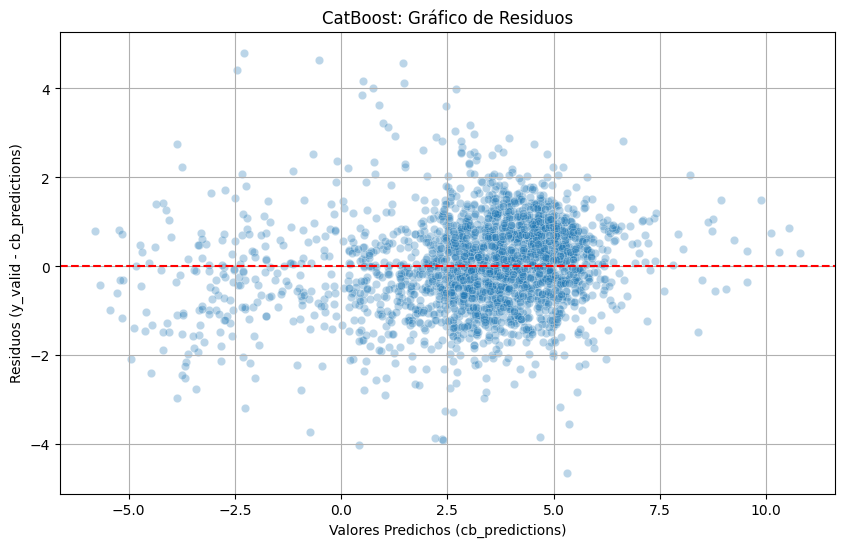

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo CatBoost Regressor
# Para CatBoost, dado que las características ya están one-hot encoded, no necesitamos pasar cat_features.
cb_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=10,
                             random_seed=0, verbose=False, # verbose=False para no imprimir el progreso
                             allow_writing_files=False) # Para evitar errores en algunos entornos

# Entrenar el modelo
print("Entrenando CatBoost Regressor...")
cb_model.fit(X_train_encoded, y_train,
              eval_set=(X_valid_encoded, y_valid),
              early_stopping_rounds=50, # Early stopping para evitar sobreajuste
              verbose=False)
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
cb_predictions = cb_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
cb_mae = mean_absolute_error(y_valid, cb_predictions)
print(f"\nError Absoluto Medio (MAE) del CatBoost: {cb_mae:.4f}")

# Calcular RMSE
cb_rmse = np.sqrt(mean_squared_error(y_valid, cb_predictions))
print(f"Root Mean Squared Error (RMSE) del CatBoost: {cb_rmse:.4f}")

# Calcular R-squared
cb_r2 = r2_score(y_valid, cb_predictions)
print(f"R-squared (R2 Score) del CatBoost: {cb_r2:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=cb_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (cb_predictions)')
plt.title('CatBoost: Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
cb_residuals = y_valid - cb_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cb_predictions, y=cb_residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (cb_predictions)')
plt.ylabel('Residuos (y_valid - cb_predictions)')
plt.title('CatBoost: Gráfico de Residuos')
plt.grid(True)
plt.show()

### Análisis de Importancia de Características



--- Importancia de Características para XGBoost ---
Top 15 características para XGBoost:


,Feature,Importance
554,TARGET_PATHWAY_Mitosis,56272.500000
133,DRUG_NAME_Dactinomycin,33340.972656
113,DRUG_NAME_Bortezomib,29645.587891
518,TARGET_TOP1,29041.689453
286,DRUG_NAME_Sepantroniumbromide,27473.535156
534,TARGET_antioxidantproteins,24899.460938
432,TARGET_HSP90,21292.738281
290,DRUG_NAME_Staurosporine,18624.791016
270,DRUG_NAME_Romidepsin,17919.457031
465,TARGET_Metabolism,15017.161133


/tmp/ipykernel_5710/2791993601.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_importance_df.head(15), palette='viridis')


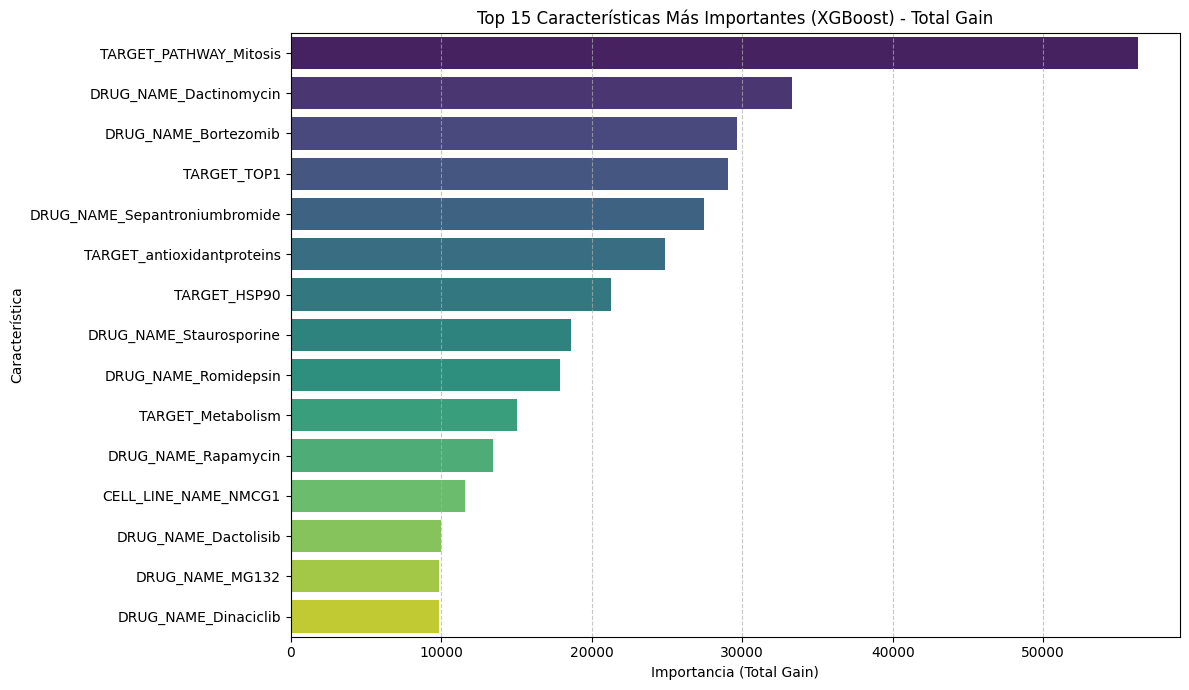

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- XGBoost Feature Importance ---
print("\n--- Importancia de Características para XGBoost ---")

# Obtener las importancias de las características del modelo entrenado
# Usamos get_booster().get_score() con importance_type='total_gain' para obtener valores no normalizados y de mayor magnitud
xgb_feature_scores = xgb_model.get_booster().get_score(importance_type='total_gain')

# Obtener los nombres de las características
feature_names = X_train_encoded.columns

# Asegurarnos de que todas las características tengan un score, si alguna no aparece, su score es 0
xgb_feature_importances = pd.Series(xgb_feature_scores).reindex(feature_names, fill_value=0)

# Crear un DataFrame para mejor visualización
xgb_importance_df = pd.DataFrame({
    'Feature': xgb_feature_importances.index,
    'Importance': xgb_feature_importances.values
})

# Ordenar por importancia y seleccionar las top N
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

# Mostrar las top 15 características
print("Top 15 características para XGBoost:")
display(xgb_importance_df.head(15))

# Visualizar las top 15 características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df.head(15), palette='viridis')
plt.title('Top 15 Características Más Importantes (XGBoost) - Total Gain')
plt.xlabel('Importancia (Total Gain)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Importancia de Características para CatBoost ---
Top 15 características para CatBoost:


,Feature,Importance
554,TARGET_PATHWAY_Mitosis,7.237790
518,TARGET_TOP1,3.912417
133,DRUG_NAME_Dactinomycin,3.843519
534,TARGET_antioxidantproteins,3.235383
432,TARGET_HSP90,2.752573
467,TARGET_Microtubulestabiliser,2.751758
286,DRUG_NAME_Sepantroniumbromide,2.412452
113,DRUG_NAME_Bortezomib,2.347543
33,CELL_LINE_NAME_NMCG1,1.849598
465,TARGET_Metabolism,1.822260


/tmp/ipykernel_5710/2138753972.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=cb_importance_df.head(15), palette='magma')


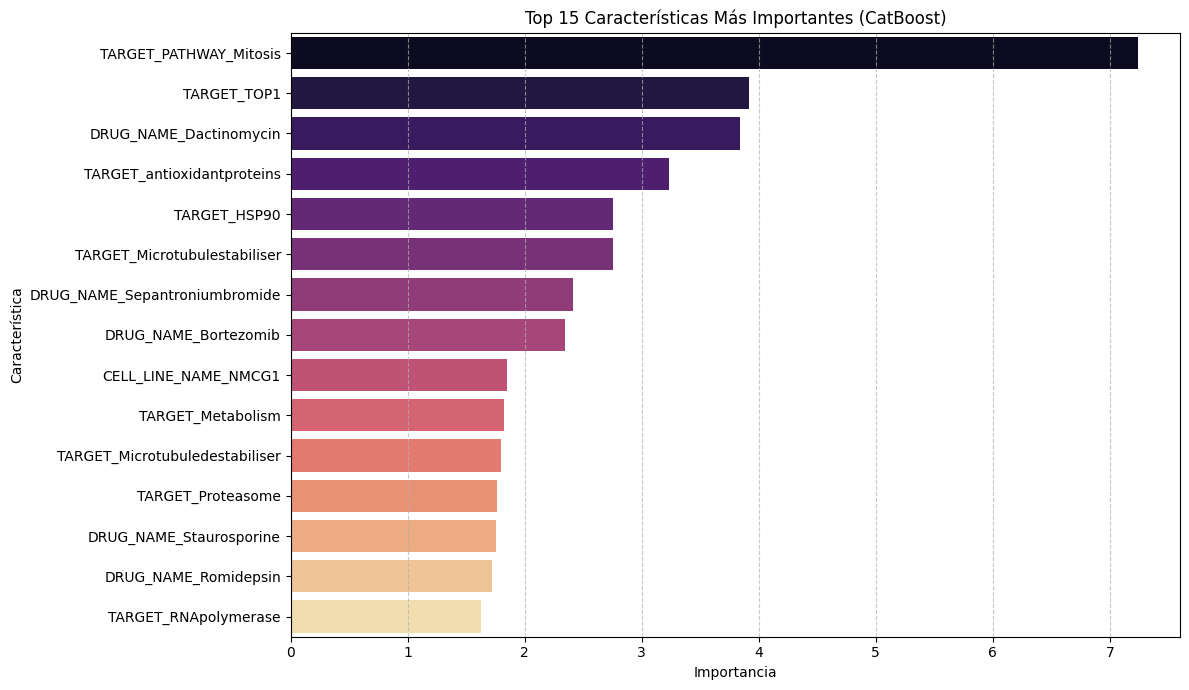

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- CatBoost Feature Importance ---
print("\n--- Importancia de Características para CatBoost ---")

# Obtener las importancias de las características del modelo entrenado
cb_feature_importances = cb_model.get_feature_importance()

# Obtener los nombres de las características
feature_names = X_train_encoded.columns

# Crear un DataFrame para mejor visualización
cb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': cb_feature_importances
})

# Ordenar por importancia y seleccionar las top N
cb_importance_df = cb_importance_df.sort_values(by='Importance', ascending=False)

# Mostrar las top 15 características
print("Top 15 características para CatBoost:")
display(cb_importance_df.head(15))

# Visualizar las top 15 características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=cb_importance_df.head(15), palette='magma')
plt.title('Top 15 Características Más Importantes (CatBoost)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Preparar Datos para Validación Cruzada



In [ ]:
import pandas as pd

# 1. Concatenar X_train_encoded y X_valid_encoded
X_combined = pd.concat([X_train_encoded, X_valid_encoded], axis=0)

# 2. Concatenar y_train e y_valid
y_combined = pd.concat([y_train, y_valid], axis=0)

print("Dimensiones de X_combined:")
print(X_combined.shape)
print("Primeras 5 filas de X_combined:")
display(X_combined.head())

print("\nDimensiones de y_combined:")
print(y_combined.shape)
print("Primeras 5 filas de y_combined:")
display(y_combined.head())

Dimensiones de X_combined:
(11822, 562)
Primeras 5 filas de X_combined:


,CELL_LINE_NAME_42MGBA,CELL_LINE_NAME_8MGBA,CELL_LINE_NAME_A172,CELL_LINE_NAME_AM38,CELL_LINE_NAME_Becker,CELL_LINE_NAME_CAS1,CELL_LINE_NAME_D245MG,CELL_LINE_NAME_D247MG,CELL_LINE_NAME_D263MG,CELL_LINE_NAME_D336MG,...,TARGET_PATHWAY_JNKandp38signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,TARGET_PATHWAY_Otherkinases,TARGET_PATHWAY_PI3KMTORsignaling,TARGET_PATHWAY_Proteinstabilityanddegradation,TARGET_PATHWAY_RTKsignaling,TARGET_PATHWAY_WNTsignaling,TARGET_PATHWAY_p53pathway
13317,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
227176,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54474,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
151213,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
62966,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Dimensiones de y_combined:
(11822,)
Primeras 5 filas de y_combined:


,LN_IC50
13317,4.858186
227176,3.625147
54474,5.590053
151213,6.676407
62966,4.539875


In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
import numpy as np

print("Necessary libraries and models for K-Fold Cross-Validation imported successfully.")

Necessary libraries and models for K-Fold Cross-Validation imported successfully.


In [ ]:
models = {
    'XGBoostRegressor': xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=0, verbosity=0), # verbosity=0 to suppress output
    'CatBoostRegressor': CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=10, random_seed=0, verbose=0, allow_writing_files=False) # verbose=0 to suppress output
}

print("Models initialized successfully.")

Models initialized successfully.


In [ ]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

# Diccionarios para almacenar los resultados
results = {
    'XGBoostRegressor': {'MAE': [], 'RMSE': [], 'R2': []},
    'CatBoostRegressor': {'MAE': [], 'RMSE': [], 'R2': []}
}

print(f"K-Fold splitter initialized with {n_splits} splits.")
print("Results dictionaries initialized.")

K-Fold splitter initialized with 5 splits.
Results dictionaries initialized.


In [ ]:
for model_name, model in models.items():
    print(f"\nRealizando validación cruzada para: {model_name}")
    fold_count = 1
    for train_index, test_index in kf.split(X_combined, y_combined):
        X_train_fold, X_test_fold = X_combined.iloc[train_index], X_combined.iloc[test_index]
        y_train_fold, y_test_fold = y_combined.iloc[train_index], y_combined.iloc[test_index]

        # Entrenar el modelo
        print(f"  Fold {fold_count}/{n_splits} - Entrenando {model_name}...")
        if model_name == 'XGBoostRegressor':
            model.fit(X_train_fold, y_train_fold, eval_set=[(X_test_fold, y_test_fold)], verbose=False)
        elif model_name == 'CatBoostRegressor':
            model.fit(X_train_fold, y_train_fold, eval_set=(X_test_fold, y_test_fold), early_stopping_rounds=50, verbose=False)
        else:
            model.fit(X_train_fold, y_train_fold)
        print(f"  Fold {fold_count}/{n_splits} - Entrenamiento completado.")

        # Realizar predicciones
        predictions = model.predict(X_test_fold)

        # Calcular métricas
        mae = mean_absolute_error(y_test_fold, predictions)
        rmse = np.sqrt(mean_squared_error(y_test_fold, predictions))
        r2 = r2_score(y_test_fold, predictions)

        # Almacenar resultados
        results[model_name]['MAE'].append(mae)
        results[model_name]['RMSE'].append(rmse)
        results[model_name]['R2'].append(r2)

        print(f"  Fold {fold_count}/{n_splits} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
        fold_count += 1

print("\nK-Fold Cross-Validation completada para todos los modelos.")


Realizando validación cruzada para: XGBoostRegressor
  Fold 1/5 - Entrenando XGBoostRegressor...
  Fold 1/5 - Entrenamiento completado.
  Fold 1/5 - MAE: 0.8265, RMSE: 1.0595, R2: 0.8524
  Fold 2/5 - Entrenando XGBoostRegressor...
  Fold 2/5 - Entrenamiento completado.
  Fold 2/5 - MAE: 0.8159, RMSE: 1.0633, R2: 0.8468
  Fold 3/5 - Entrenando XGBoostRegressor...
  Fold 3/5 - Entrenamiento completado.
  Fold 3/5 - MAE: 0.8207, RMSE: 1.0566, R2: 0.8504
  Fold 4/5 - Entrenando XGBoostRegressor...
  Fold 4/5 - Entrenamiento completado.
  Fold 4/5 - MAE: 0.8052, RMSE: 1.0320, R2: 0.8536
  Fold 5/5 - Entrenando XGBoostRegressor...
  Fold 5/5 - Entrenamiento completado.
  Fold 5/5 - MAE: 0.8022, RMSE: 1.0349, R2: 0.8536

Realizando validación cruzada para: CatBoostRegressor
  Fold 1/5 - Entrenando CatBoostRegressor...
  Fold 1/5 - Entrenamiento completado.
  Fold 1/5 - MAE: 0.8141, RMSE: 1.0339, R2: 0.8595
  Fold 2/5 - Entrenando CatBoostRegressor...
  Fold 2/5 - Entrenamiento completado.
  

In [ ]:
print("\n--- Resumen de la Validación Cruzada (Métricas Promedio) ---")
print("\nModelo                      | MAE Promedio | RMSE Promedio | R2 Promedio")
print("----------------------------|--------------|---------------|-------------")

for model_name, metrics in results.items():
    avg_mae = np.mean(metrics['MAE'])
    avg_rmse = np.mean(metrics['RMSE'])
    avg_r2 = np.mean(metrics['R2'])
    print(f"{model_name:<27} | {avg_mae:<12.4f} | {avg_rmse:<13.4f} | {avg_r2:<11.4f}")

print("----------------------------|--------------|---------------|-------------")


--- Resumen de la Validación Cruzada (Métricas Promedio) ---

Modelo                      | MAE Promedio | RMSE Promedio | R2 Promedio
----------------------------|--------------|---------------|-------------
XGBoostRegressor            | 0.8141       | 1.0493        | 0.8514     
CatBoostRegressor           | 0.7974       | 1.0240        | 0.8584     
----------------------------|--------------|---------------|-------------


### Análisis de Importancia de Características (Post-Validación Cruzada)

Vamos a extraer y visualizar las características más importantes para cada uno de los modelos después de la validación cruzada. Esto nos dará una perspectiva del modelo final.


--- Importancia de Características para XGBoost (Post-CV) ---
Top 15 características para XGBoost (Post-CV):


,Feature,Importance
554,TARGET_PATHWAY_Mitosis,54062.675781
133,DRUG_NAME_Dactinomycin,31017.978516
113,DRUG_NAME_Bortezomib,28237.544922
286,DRUG_NAME_Sepantroniumbromide,26476.857422
518,TARGET_TOP1,25351.876953
534,TARGET_antioxidantproteins,23026.730469
432,TARGET_HSP90,21314.244141
290,DRUG_NAME_Staurosporine,19834.177734
270,DRUG_NAME_Romidepsin,19783.062500
465,TARGET_Metabolism,14712.726562


/tmp/ipykernel_5710/3189351160.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_cv_importance_df.head(15), palette='viridis')


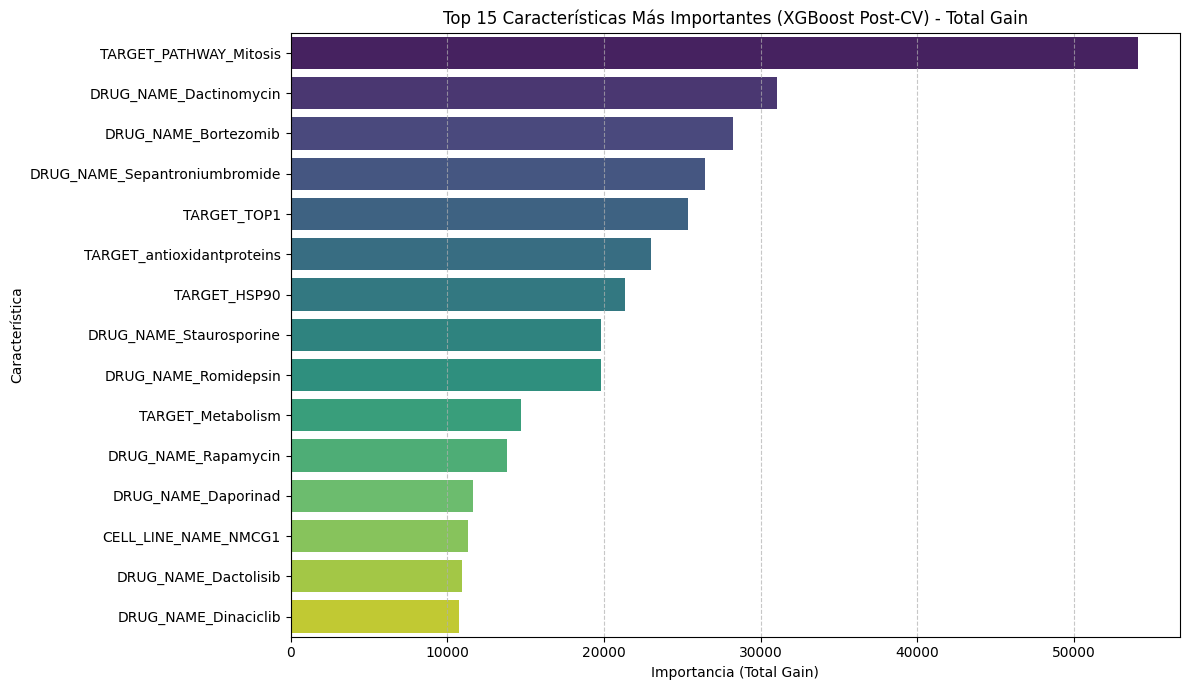

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- XGBoost Feature Importance (Post-CV) ---
print("\n--- Importancia de Características para XGBoost (Post-CV) ---")

# Obtener las importancias de las características del modelo entrenado (último fold de CV)
xgb_cv_model = models['XGBoostRegressor']
xgb_cv_feature_scores = xgb_cv_model.get_booster().get_score(importance_type='total_gain')

# Obtener los nombres de las características del conjunto combinado
feature_names_combined = X_combined.columns

# Asegurarnos de que todas las características tengan un score, si alguna no aparece, su score es 0
xgb_cv_feature_importances = pd.Series(xgb_cv_feature_scores).reindex(feature_names_combined, fill_value=0)

# Crear un DataFrame para mejor visualización
xgb_cv_importance_df = pd.DataFrame({
    'Feature': xgb_cv_feature_importances.index,
    'Importance': xgb_cv_feature_importances.values
})

# Ordenar por importancia y seleccionar las top N
xgb_cv_importance_df = xgb_cv_importance_df.sort_values(by='Importance', ascending=False)

# Mostrar las top 15 características
print("Top 15 características para XGBoost (Post-CV):")
display(xgb_cv_importance_df.head(15))

# Visualizar las top 15 características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_cv_importance_df.head(15), palette='viridis')
plt.title('Top 15 Características Más Importantes (XGBoost Post-CV) - Total Gain')
plt.xlabel('Importancia (Total Gain)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


--- Importancia de Características para CatBoost (Post-CV) ---
Top 15 características para CatBoost (Post-CV):


,Feature,Importance
554,TARGET_PATHWAY_Mitosis,6.158668
518,TARGET_TOP1,3.628456
467,TARGET_Microtubulestabiliser,3.614443
133,DRUG_NAME_Dactinomycin,3.271888
534,TARGET_antioxidantproteins,3.020908
432,TARGET_HSP90,2.706262
286,DRUG_NAME_Sepantroniumbromide,2.483724
495,TARGET_Proteasome,2.156925
33,CELL_LINE_NAME_NMCG1,1.916432
290,DRUG_NAME_Staurosporine,1.902612


/tmp/ipykernel_5710/1724003461.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=cb_cv_importance_df.head(15), palette='magma')


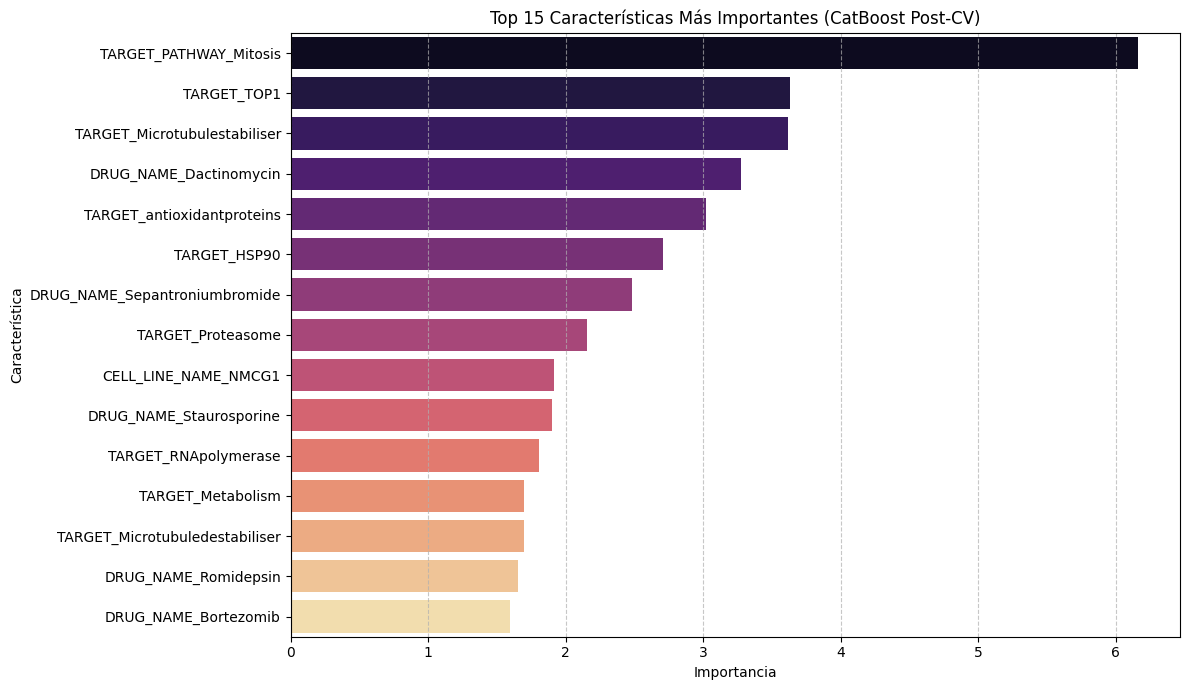

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- CatBoost Feature Importance (Post-CV) ---
print("\n--- Importancia de Características para CatBoost (Post-CV) ---")

# Obtener las importancias de las características del modelo entrenado (último fold de CV)
cb_cv_model = models['CatBoostRegressor']
cb_cv_feature_importances = cb_cv_model.get_feature_importance()

# Obtener los nombres de las características del conjunto combinado
feature_names_combined = X_combined.columns

# Crear un DataFrame para mejor visualización
cb_cv_importance_df = pd.DataFrame({
    'Feature': feature_names_combined,
    'Importance': cb_cv_feature_importances
})

# Ordenar por importancia y seleccionar las top N
cb_cv_importance_df = cb_cv_importance_df.sort_values(by='Importance', ascending=False)

# Mostrar las top 15 características
print("Top 15 características para CatBoost (Post-CV):")
display(cb_cv_importance_df.head(15))

# Visualizar las top 15 características
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=cb_cv_importance_df.head(15), palette='magma')
plt.title('Top 15 Características Más Importantes (CatBoost Post-CV)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()